In [27]:
#####Q1 — Import Dataset
import pandas as pd

# loading the file exported from SQL section
df = pd.read_csv('pollution_sql_output.csv')

# just checking what we loaded
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print(df.head())

Total rows: 5000
Total columns: 12
   Year       City    State        Season River_Name Industry_Sector  Avg_AQI  \
0  2010  Ahmedabad  Gujarat       Monsoon       Beas   Agro-Industry   129.27   
1  2010  Ahmedabad  Gujarat       Monsoon  Sabarmati        Chemical   130.64   
2  2010  Ahmedabad  Gujarat  Post-Monsoon  Sabarmati        Chemical   141.75   
3  2010  Ahmedabad  Gujarat        Summer       Beas   Agro-Industry    99.12   
4  2010  Ahmedabad  Gujarat        Summer  Sabarmati        Chemical   129.32   

   Avg_Water  Avg_Emission  Avg_Vehicles    Avg_GDP  Avg_Population  
0       1.56      275726.0     1942771.0   859516.0          4543.0  
1       1.84       27020.0      142244.0   859516.0          4543.0  
2       1.45       28706.0      142244.0   859516.0          4543.0  
3       1.81      275726.0     1942771.0  2521456.0          3999.0  
4       1.65       47380.0      142244.0  4183396.0          3455.0  


In [29]:
# checking empty cells first
print("Missing values:")
print(df.isnull().sum())

# filling empty cells with average
df['Avg_AQI'] = df['Avg_AQI'].fillna(df['Avg_AQI'].mean())
df['Avg_Water'] = df['Avg_Water'].fillna(df['Avg_Water'].median())

# confirming no more empty cells
print("After cleaning:", df.isnull().sum().sum())
print("Dataset is clean!")

Missing values:
Year               0
City               0
State              0
Season             0
River_Name         0
Industry_Sector    0
Avg_AQI            0
Avg_Water          0
Avg_Emission       0
Avg_Vehicles       0
Avg_GDP            0
Avg_Population     0
dtype: int64
After cleaning: 0
Dataset is clean!


                Avg_AQI  Avg_Emission  Avg_Population  Avg_Vehicles  Avg_Water
Avg_AQI            1.00          0.01           -0.08          0.07      -0.01
Avg_Emission       0.01          1.00            0.25         -0.10       0.27
Avg_Population    -0.08          0.25            1.00         -0.22       0.01
Avg_Vehicles       0.07         -0.10           -0.22          1.00       0.55
Avg_Water         -0.01          0.27            0.01          0.55       1.00


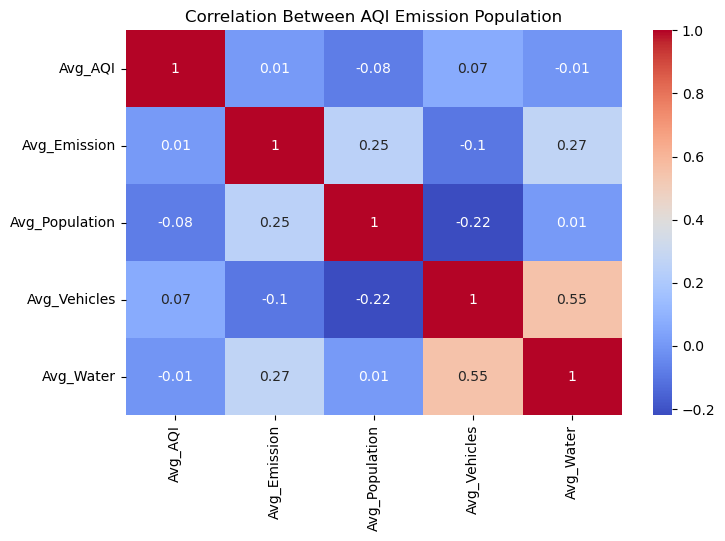

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# picking columns to compare
cols = ['Avg_AQI', 'Avg_Emission', 'Avg_Population',
        'Avg_Vehicles', 'Avg_Water']

# calculating how related each column is
correlation = df[cols].corr().round(2)
print(correlation)

# drawing heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between AQI Emission Population')
plt.show()

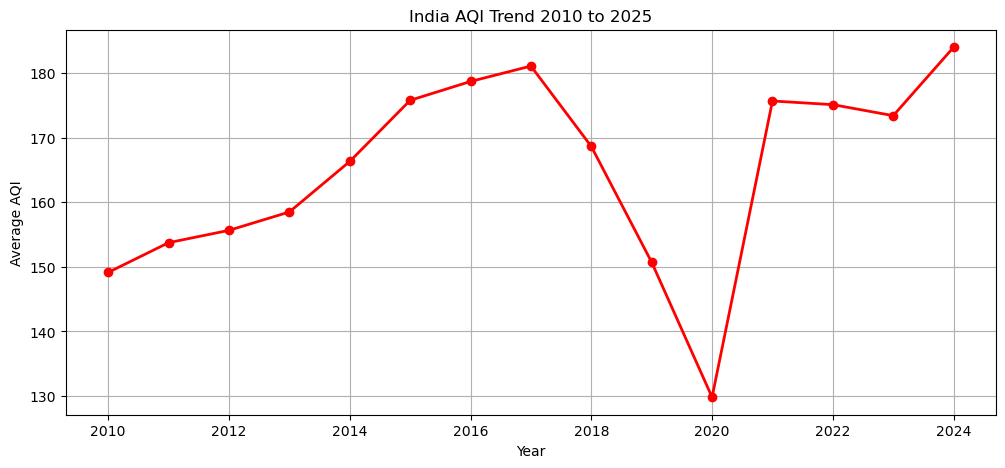

In [33]:
####Q4 — AQI Trend Line Graph
import matplotlib.pyplot as plt

# average AQI per year
yearly = df.groupby('Year')['Avg_AQI'].mean().reset_index()

# drawing line chart
plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Avg_AQI'],
         color='red', marker='o', linewidth=2)
plt.title('India AQI Trend 2010 to 2025')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()

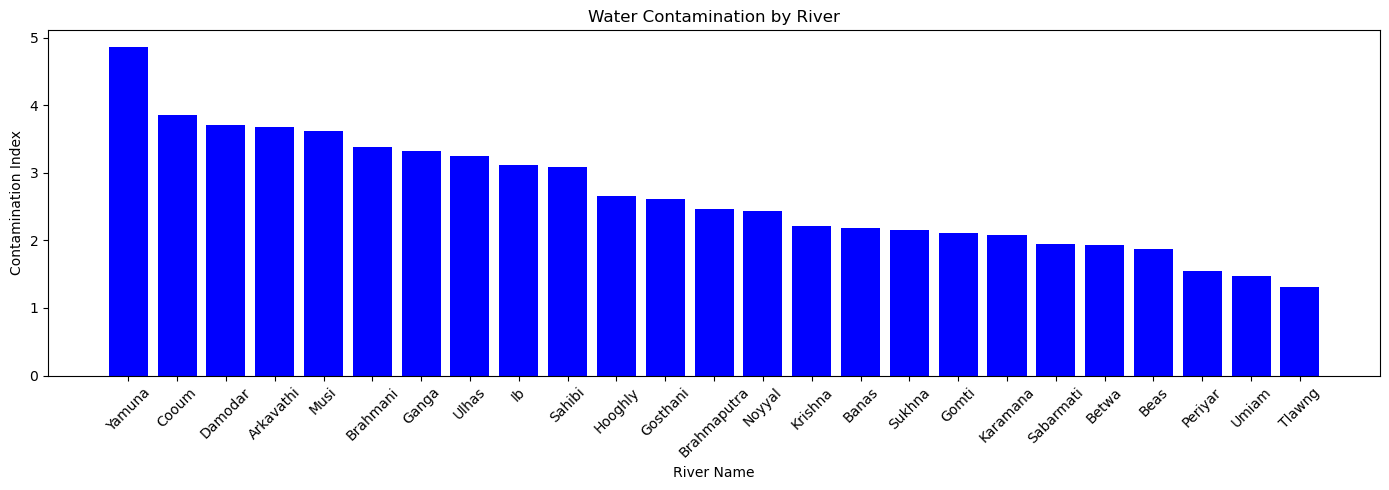

In [34]:
####Q5 — Water Contamination by River
import matplotlib.pyplot as plt

# average contamination per river sorted highest first
river = df.groupby('River_Name')['Avg_Water'].mean()
river = river.sort_values(ascending=False)

# drawing bar chart
plt.figure(figsize=(14, 5))
plt.bar(river.index, river.values, color='blue')
plt.title('Water Contamination by River')
plt.xlabel('River Name')
plt.ylabel('Contamination Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
####Q6 — Year over Year AQI Change

# average AQI per year
yearly = df.groupby('Year')['Avg_AQI'].mean().reset_index()
yearly.columns = ['Year', 'Avg_AQI']

# diff gives change from previous year
yearly['Change'] = yearly['Avg_AQI'].diff().round(2)

# fill 2010 NaN with 0 since its the base year
yearly['Change'] = yearly['Change'].fillna(0)

# simple label for direction
yearly['Trend'] = yearly['Change'].apply(
    lambda x: 'Base Year' if x == 0 else ('Improving' if x < 0 else 'Worsening')
)

print(yearly)

    Year     Avg_AQI  Change      Trend
0   2010  149.137273    0.00  Base Year
1   2011  153.736233    4.60  Worsening
2   2012  155.644553    1.91  Worsening
3   2013  158.485837    2.84  Worsening
4   2014  166.298981    7.81  Worsening
5   2015  175.754769    9.46  Worsening
6   2016  178.673429    2.92  Worsening
7   2017  181.057182    2.38  Worsening
8   2018  168.625455  -12.43  Improving
9   2019  150.708719  -17.92  Improving
10  2020  129.830513  -20.88  Improving
11  2021  175.653292   45.82  Worsening
12  2022  175.088643   -0.56  Improving
13  2023  173.384299   -1.70  Improving
14  2024  183.970841   10.59  Worsening


In [36]:
####Q7 — GroupBy Industry Sector
# grouping by industry and summing emissions
sector = df.groupby('Industry_Sector').agg(
    Total_Emission = ('Avg_Emission', 'sum'),
    Avg_AQI        = ('Avg_AQI', 'mean')
).reset_index()

# sorting worst polluter first
sector = sector.sort_values('Total_Emission', ascending=False)
print(sector.round(2))

      Industry_Sector  Total_Emission  Avg_AQI
8       Manufacturing    3.467329e+08   163.97
10        Mining/Coal    2.498629e+08   176.07
11              Power    2.423659e+08   167.70
2          Automobile    2.251285e+08   164.90
0       Agro-Industry    1.514298e+08   170.46
4          Coal/Power    1.199624e+08   168.04
13      Thermal Power    1.181233e+08   149.50
3            Chemical    3.810739e+07   195.25
1     Agro-processing    3.622950e+07   121.32
7      IT/Electronics    2.653209e+07   133.61
12  Shipping/Refinery    1.674409e+07   186.49
6         Handicrafts    9.235069e+06    99.67
9              Mining    7.770635e+06   172.67
5              Energy    6.560299e+06   144.08


In [37]:
####Q8 — Export to Excel
# creating summary dataset
summary = df.groupby(['Year', 'City', 'State']).agg(
    Avg_AQI      = ('Avg_AQI', 'mean'),
    Avg_Water    = ('Avg_Water', 'mean'),
    Avg_Emission = ('Avg_Emission', 'mean')
).reset_index().round(2)

# saving to Excel
summary.to_excel('pollution_processed.xlsx',
                 sheet_name='Clean_Data',
                 index=False)

print("File saved!")
print("Total rows:", len(summary))

File saved!
Total rows: 660


In [38]:
####9.Auto Report Generation
from datetime import datetime

# calculating key numbers
avg_aqi       = round(df['Avg_AQI'].mean(), 2)
worst_city    = df.groupby('City')['Avg_AQI'].mean().idxmax()
cleanest_city = df.groupby('City')['Avg_AQI'].mean().idxmin()
worst_river   = df.groupby('River_Name')['Avg_Water'].mean().idxmax()
worst_sector  = df.groupby('Industry_Sector')['Avg_Emission'].sum().idxmax()
worst_season  = df.groupby('Season')['Avg_AQI'].mean().idxmax()

# writing report automatically
report = f"""
INDIA POLLUTION REPORT
Date             : {datetime.now().strftime('%d-%m-%Y')}
Average AQI      : {avg_aqi}
Most Polluted City   : {worst_city}
Cleanest City        : {cleanest_city}
Most Polluted River  : {worst_river}
Top Polluting Sector : {worst_sector}
Worst Season         : {worst_season}
"""

print(report)

# saving report to text file
with open('pollution_report.txt', 'w') as f:
    f.write(report)

print("Report saved successfully!")


INDIA POLLUTION REPORT
Date             : 30-05-2026
Average AQI      : 163.74
Most Polluted City   : Ahmedabad
Cleanest City        : Aizawl
Most Polluted River  : Yamuna
Top Polluting Sector : Manufacturing
Worst Season         : Winter

Report saved successfully!


In [40]:
####Q10 — Season AQI for Power BI
# creating final file for Power BI
powerbi = df.groupby(
    ['Year', 'City', 'State', 'Season', 'River_Name']
).agg(
    Avg_AQI      = ('Avg_AQI', 'mean'),
    Avg_Water    = ('Avg_Water', 'mean'),
    Avg_Emission = ('Avg_Emission', 'mean'),
    Avg_Vehicles = ('Avg_Vehicles', 'mean'),
    Avg_GDP      = ('Avg_GDP', 'mean')
).reset_index().round(2)

# saving as CSV
powerbi.to_csv('pollution_for_powerbi.csv', index=False)

print("Power BI file saved!")
print("Total rows:", len(powerbi))

Power BI file saved!
Total rows: 3793
